# BCI2000 Neural-Behavior Follow-up Analysis

This notebook follows up on the first exploratory analysis and focuses on the results that were most useful or most in need of validation.

It does four main things:

1. **Validate the HL17 Ordered vs Pseudorandom result**
   - trial-level distributions
   - time-resolved HFB around `MovementStarted`
   - time-frequency comparison

2. **Check whether the widespread movement-related HFB decrease is global/common-mode**
   - distribution across contacts
   - trial-level global HFB trend
   - adjacent-contact bipolar sensitivity analysis
   - 120 Hz line-noise change

3. **Repair target-direction analysis**
   - inspect the raw `TargetAngle`
   - derive direction from `TargetX` and `TargetY`
   - use continuous circular regression rather than requiring repeated identical angles

4. **Use the eye-tracking states**
   - inspect actual gaze coordinate ranges and validity states
   - build a combined binocular gaze trace when possible
   - summarize pre-movement gaze behavior by trial
   - correlate gaze behavior with neural HFB
   - compare gaze behavior across task contexts

This remains exploratory. Significant associations are candidates for follow-up, not proof of causal or physiological involvement.


In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.signal import (
    welch,
    butter,
    sosfiltfilt,
    hilbert,
    iirnotch,
    filtfilt,
    stft,
)
from scipy.stats import (
    ttest_1samp,
    ttest_ind,
    spearmanr,
    f as f_distribution,
)

from BCI2000Tools.FileReader import bcistream

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 120)


## 1. Select the recording


In [2]:
DAT_PATH = Path(
    r"C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat"
)

if not DAT_PATH.is_file():
    raise FileNotFoundError(
        f"File not found: {DAT_PATH}\n"
        "Edit DAT_PATH above so it points to the correct BCI2000 .dat file."
    )

print(f"Using: {DAT_PATH.resolve()}")


Using: C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat


## 2. Open the file and decode signal + task + eye-tracking states

Eye-related states are discovered dynamically from the file rather than hard-coded from the earlier populated-state list.


In [3]:
stream = bcistream(str(DAT_PATH))

core_states = [
    "CursorX",
    "CursorY",
    "TaskPhase",
    "TaskCondition",
    "TaskBlockType",
    "TargetAngle",
    "TargetX",
    "TargetY",
    "TaskBlock",
    "TaskTrial",
    "MovementStarted",
    "TargetHit",
    "Introduction",
    "TutorialPhase",
    "PracticeTrial",
    "ReactionTimeMs",
    "MovementTimeMs",
    "TotalTimeMs",
    "JoystickXpos",
    "JoystickYpos",
    "JoystickButtons1",
    "PresentationRequested",
    "PresentationDisplayed",
    "PresentationTime",
    "PresentationFrame",
    "Running",
    "Recording",
]

eye_states = [
    name
    for name in stream.statedefs.keys()
    if ("eye" in name.lower() or "gaze" in name.lower())
]

requested_states = list(dict.fromkeys(core_states + eye_states))

available_states = [
    name for name in requested_states
    if name in stream.statedefs
]

signal_raw, decoded_states = stream.decode(
    nsamp="all",
    states=available_states,
)

signal_raw = np.asarray(signal_raw)

n_channels = int(stream.nchan)
n_samples = int(stream.samples())
fs = float(stream.samplingfreq_hz)

if signal_raw.shape == (n_channels, n_samples):
    signal = signal_raw.T
elif signal_raw.shape == (n_samples, n_channels):
    signal = signal_raw
else:
    raise ValueError(
        f"Unexpected decoded signal shape: {signal_raw.shape}"
    )

states = {
    name: np.asarray(decoded_states[name]).ravel()
    for name in available_states
}

print(f"Signal shape:   {signal.shape}  (samples x channels)")
print(f"Sampling rate: {fs:g} Hz")
print(f"Duration:      {n_samples / fs / 60:.2f} minutes")
print(f"States decoded: {len(states)}")
print(f"Eye/gaze states decoded: {len([s for s in states if 'eye' in s.lower() or 'gaze' in s.lower()])}")


Signal shape:   (1255100, 256)  (samples x channels)
Sampling rate: 2000 Hz
Duration:      10.46 minutes
States decoded: 44
Eye/gaze states decoded: 20


## 3. Map intracranial channel labels to implant targets

These region labels come from the implantation sheet. They are electrode-target labels, not CT/MRI-confirmed contact localization.


In [4]:
channel_names = [
    str(name).strip()
    for name in stream.params["ChannelNames"]
]

implant_targets = {
    "AL": "L temporal pole",
    "BL": "L amygdala",
    "CL": "L hippocampal head",
    "DL": "L hippocampal tail",
    "EL": "L fusiform",
    "FL": "L orbitofrontal",
    "GL": "L opercular",
    "HL": "L anterior insula ventral",
    "IL": "L posterior insula",
    "AR": "R temporal pole",
    "BR": "R amygdala",
    "CR": "R hippocampal head",
    "DR": "R hippocampal tail",
    "ER": "R fusiform",
    "FR": "R orbitofrontal",
    "GR": "R opercular",
    "HR": "R anterior insula ventral",
    "IR": "R posterior insula",
}

rows = []

for signal_index, name in enumerate(channel_names):
    match = re.fullmatch(r"([A-Z]{2})(\d+)", name)

    if match and match.group(1) in implant_targets:
        electrode = match.group(1)

        rows.append({
            "signal_index": signal_index,
            "BCI2000_channel": signal_index + 1,
            "channel_name": name,
            "electrode": electrode,
            "contact": int(match.group(2)),
            "implant_target": implant_targets[electrode],
        })

intracranial_channels = pd.DataFrame(rows)
intracranial_indices = intracranial_channels["signal_index"].to_numpy()
intracranial_names = intracranial_channels["channel_name"].to_numpy()

print(f"Intracranial contacts: {len(intracranial_channels)}")
display(intracranial_channels.head(25))


Intracranial contacts: 202


,signal_index,BCI2000_channel,channel_name,electrode,contact,implant_target
0,0,1,AL1,AL,1,L temporal pole
1,1,2,AL2,AL,2,L temporal pole
2,2,3,AL3,AL,3,L temporal pole
3,3,4,AL4,AL,4,L temporal pole
4,6,7,AL5,AL,5,L temporal pole
5,7,8,AL6,AL,6,L temporal pole
6,8,9,AL7,AL,7,L temporal pole
7,9,10,AL8,AL,8,L temporal pole
8,10,11,AL9,AL,9,L temporal pole
9,11,12,AL10,AL,10,L temporal pole


## 4. Build one row per completed experimental trial

The trial table stores both the behavioral values and the neural-event timing needed for the later analyses.

It also stores target coordinates at movement onset and at target hit so we can diagnose why the earlier `TargetAngle` analysis produced almost one unique angle per trial.


In [5]:
def rising_edges(values):
    values = np.asarray(values)
    active = values > 0

    edges = np.flatnonzero(
        active[1:] & ~active[:-1]
    ) + 1

    if active.size and active[0]:
        edges = np.r_[0, edges]

    return edges.astype(int)


for needed in ["TaskBlock", "TaskTrial", "MovementStarted", "TargetHit"]:
    if needed not in states:
        raise KeyError(f"Required state missing: {needed}")

movement_onsets = rising_edges(states["MovementStarted"])
hit_samples = rising_edges(states["TargetHit"])

experimental_mask = np.ones(n_samples, dtype=bool)

if "Introduction" in states:
    experimental_mask &= states["Introduction"] == 0

experimental_mask &= states["TaskBlock"] > 0
experimental_mask &= states["TaskTrial"] > 0

if "PracticeTrial" in states:
    experimental_mask &= states["PracticeTrial"] == 0

movement_onsets = movement_onsets[
    experimental_mask[movement_onsets]
]

hit_samples = hit_samples[
    experimental_mask[hit_samples]
]

trial_rows = []

for hit in hit_samples:
    block = int(states["TaskBlock"][hit])
    trial = int(states["TaskTrial"][hit])

    candidates = movement_onsets[
        (movement_onsets <= hit)
        & (states["TaskBlock"][movement_onsets] == block)
        & (states["TaskTrial"][movement_onsets] == trial)
    ]

    if candidates.size == 0:
        continue

    onset = int(candidates[-1])

    same_trial = np.flatnonzero(
        (states["TaskBlock"] == block)
        & (states["TaskTrial"] == trial)
    )

    if same_trial.size == 0:
        continue

    trial_start = int(same_trial[0])

    row = {
        "block": block,
        "trial": trial,
        "trial_start_sample": trial_start,
        "movement_onset_sample": onset,
        "target_hit_sample": int(hit),
        "trial_start_s": trial_start / fs,
        "movement_onset_s": onset / fs,
        "target_hit_s": hit / fs,
    }

    for state_name in [
        "TaskCondition",
        "TaskBlockType",
        "TargetAngle",
        "ReactionTimeMs",
        "MovementTimeMs",
        "TotalTimeMs",
    ]:
        if state_name in states:
            row[state_name] = states[state_name][hit]

    for coord in ["TargetX", "TargetY"]:
        if coord in states:
            row[f"{coord}_start"] = states[coord][trial_start]
            row[f"{coord}_move"] = states[coord][onset]
            row[f"{coord}_hit"] = states[coord][hit]

    if "JoystickXpos" in states and "JoystickYpos" in states:
        x = states["JoystickXpos"][onset:hit + 1].astype(float)
        y = states["JoystickYpos"][onset:hit + 1].astype(float)

        if len(x) >= 2:
            step = np.hypot(np.diff(x), np.diff(y))
            row["joystick_path"] = np.nansum(step)
            row["joystick_peak_step"] = np.nanmax(step)

    trial_rows.append(row)

trials = pd.DataFrame(trial_rows)

if trials.empty:
    raise RuntimeError("No completed trials were matched.")

if "TaskCondition" in trials:
    trials["condition"] = trials["TaskCondition"].map({
        0: "Automatic",
        1: "Controlled",
    })

if "TaskBlockType" in trials:
    trials["context"] = np.where(
        trials["TaskBlockType"] == 2,
        "Pseudorandom",
        "Ordered",
    )

print(f"Matched completed trials: {len(trials)}")

summary = {
    "completed_trials": len(trials),
}

if "condition" in trials:
    summary["automatic"] = int((trials["condition"] == "Automatic").sum())
    summary["controlled"] = int((trials["condition"] == "Controlled").sum())

if "context" in trials:
    summary["ordered"] = int((trials["context"] == "Ordered").sum())
    summary["pseudorandom"] = int((trials["context"] == "Pseudorandom").sum())

display(pd.Series(summary, name="count").to_frame())
display(trials.head(15))


Matched completed trials: 80


,count
completed_trials,80
automatic,40
controlled,40
ordered,20
pseudorandom,60


,block,trial,trial_start_sample,movement_onset_sample,target_hit_sample,trial_start_s,movement_onset_s,target_hit_s,TaskCondition,TaskBlockType,TargetAngle,ReactionTimeMs,MovementTimeMs,TotalTimeMs,TargetX_start,TargetX_move,TargetX_hit,TargetY_start,TargetY_move,TargetY_hit,joystick_path,joystick_peak_step,condition,context
0,1,1,100,24600,28400,0.05,12.30,14.20,0,0,1276,949,1900,2849,359,359,359,776,776,776,37354.902718,674.569492,Automatic,Ordered
1,1,2,29400,40300,42500,14.70,20.15,21.25,0,0,2256,751,1100,1851,336,336,336,273,273,273,14494.895456,232.963516,Automatic,Ordered
2,1,3,43600,52900,53900,21.80,26.45,26.95,0,0,1509,450,500,950,293,293,293,674,674,674,9135.509951,316.077522,Automatic,Ordered
3,1,4,54900,64100,65200,27.45,32.05,32.60,0,0,1253,500,550,1050,367,367,367,784,784,784,4909.604742,173.254149,Automatic,Ordered
4,1,5,66300,74900,78600,33.15,37.45,39.30,0,0,2441,200,1850,2050,402,402,402,211,211,211,45117.367384,374.550397,Automatic,Ordered
5,1,6,79600,96300,100300,39.80,48.15,50.15,0,0,210,700,2000,2700,745,745,745,631,631,631,23765.741839,274.696196,Automatic,Ordered
6,1,7,101300,110600,111600,50.65,55.30,55.80,0,0,1274,549,501,1050,359,359,359,777,777,777,10129.161576,250.697028,Automatic,Ordered
7,1,8,112700,121900,123300,56.35,60.95,61.65,0,0,2136,550,700,1251,303,303,303,327,327,327,8941.488188,186.590461,Automatic,Ordered
8,1,9,124400,133700,133900,62.20,66.85,66.95,0,0,3353,499,100,598,739,739,739,372,372,372,2010.027207,181.727818,Automatic,Ordered
9,1,10,134900,144100,145300,67.45,72.05,72.65,0,0,3008,500,599,1099,640,640,640,224,224,224,10623.547812,192.000000,Automatic,Ordered


# Part A: Validate the movement-related HFB findings

The earlier notebook found a widespread decrease in 70 to 150 Hz power after movement onset. This section reproduces that result and then asks whether it looks local or globally shared across the recording.


In [7]:
BASELINE_WINDOW_S = (-0.75, -0.25)
MOVEMENT_WINDOW_S = (0.00, 0.50)

BANDS = {
    "beta": (13.0, 30.0),
    "hfb": (70.0, 150.0),
}

LINE_NOISE_FREQS = (60.0, 120.0, 180.0)
LINE_HALF_WIDTH_HZ = 2.0


def spectral_density(segment, fs):
    nperseg = min(
        segment.shape[0],
        max(64, int(round(fs * 0.25))),
    )

    f, pxx = welch(
        segment,
        fs=fs,
        axis=0,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="constant",
        scaling="density",
    )

    return f, pxx


def integrate_band(
    f,
    pxx,
    low,
    high,
    remove_line_noise=True,
):
    mask = (f >= low) & (f <= high)

    if remove_line_noise:
        for line_freq in LINE_NOISE_FREQS:
            mask &= (
                np.abs(f - line_freq)
                > LINE_HALF_WIDTH_HZ
            )

    if mask.sum() < 2:
        raise ValueError(
            f"Not enough frequency bins in {low}-{high} Hz."
        )

    return np.trapezoid(
        pxx[mask],
        f[mask],
        axis=0,
    )


def frequency_bin_power(
    f,
    pxx,
    target_frequency,
):
    """
    Return PSD power from the frequency bin
    closest to target_frequency.
    """

    index = np.argmin(
        np.abs(f - target_frequency)
    )

    return pxx[index]


band_responses = {
    band_name: []
    for band_name in BANDS
}

line120_change_db = []
kept_trials = []

for trial_index, row in trials.iterrows():

    onset = int(
        row["movement_onset_sample"]
    )

    b0 = onset + int(
        round(
            BASELINE_WINDOW_S[0]
            * fs
        )
    )

    b1 = onset + int(
        round(
            BASELINE_WINDOW_S[1]
            * fs
        )
    )

    m0 = onset + int(
        round(
            MOVEMENT_WINDOW_S[0]
            * fs
        )
    )

    m1 = onset + int(
        round(
            MOVEMENT_WINDOW_S[1]
            * fs
        )
    )

    # Skip trials whose windows fall
    # outside the recording.
    if (
        b0 < 0
        or b1 > n_samples
        or m0 < 0
        or m1 > n_samples
    ):
        continue

    baseline = signal[
        b0:b1,
        intracranial_indices,
    ].astype(
        np.float64
    )

    movement = signal[
        m0:m1,
        intracranial_indices,
    ].astype(
        np.float64
    )

    f_b, psd_b = spectral_density(
        baseline,
        fs,
    )

    f_m, psd_m = spectral_density(
        movement,
        fs,
    )

    if not np.allclose(
        f_b,
        f_m,
    ):
        raise RuntimeError(
            "Baseline and movement frequency bins differ."
        )

    # ---------------------------------
    # Beta and HFB band-power responses
    # ---------------------------------

    for band_name, (
        low,
        high,
    ) in BANDS.items():

        base_power = integrate_band(
            f_b,
            psd_b,
            low,
            high,
            remove_line_noise=True,
        )

        move_power = integrate_band(
            f_m,
            psd_m,
            low,
            high,
            remove_line_noise=True,
        )

        eps = np.finfo(
            float
        ).tiny

        response_db = (
            10
            * np.log10(
                (
                    move_power
                    + eps
                )
                /
                (
                    base_power
                    + eps
                )
            )
        )

        band_responses[
            band_name
        ].append(
            response_db
        )

    # ---------------------------------
    # 120 Hz line-noise harmonic
    # ---------------------------------
    #
    # Welch resolution here is about
    # 4 Hz, so 118-122 Hz contains only
    # one spectral bin.
    #
    # Instead of integrating a band,
    # take the PSD bin closest to 120 Hz.

    base_120 = frequency_bin_power(
        f_b,
        psd_b,
        120.0,
    )

    move_120 = frequency_bin_power(
        f_m,
        psd_m,
        120.0,
    )

    eps = np.finfo(
        float
    ).tiny

    line120_change_db.append(
        10
        * np.log10(
            (
                move_120
                + eps
            )
            /
            (
                base_120
                + eps
            )
        )
    )

    kept_trials.append(
        trial_index
    )


# Convert trial lists into
# trials x channels arrays.

for band_name in band_responses:

    if len(
        band_responses[
            band_name
        ]
    ) == 0:
        raise RuntimeError(
            f"No valid trials were retained for {band_name}."
        )

    band_responses[
        band_name
    ] = np.vstack(
        band_responses[
            band_name
        ]
    )


if len(
    line120_change_db
) == 0:
    raise RuntimeError(
        "No valid trials were retained for the 120 Hz analysis."
    )

line120_change_db = np.vstack(
    line120_change_db
)


# Keep the trial table synchronized
# with the neural arrays.

neural_trials = trials.loc[
    kept_trials
].reset_index(
    drop=True
)


# These variable names are preserved
# because later cells depend on them.

hfb = band_responses[
    "hfb"
]

beta = band_responses[
    "beta"
]


print(
    f"Neural trials retained: "
    f"{len(neural_trials)}"
)

print(
    f"HFB matrix: "
    f"{hfb.shape}"
)

print(
    f"Beta matrix: "
    f"{beta.shape}"
)

print(
    f"120 Hz matrix: "
    f"{line120_change_db.shape}"
)

print(
    f"Welch frequency resolution: "
    f"{f_b[1] - f_b[0]:.2f} Hz"
)

closest_120_index = np.argmin(
    np.abs(
        f_b - 120.0
    )
)

print(
    f"120 Hz measurement uses "
    f"{f_b[closest_120_index]:.2f} Hz bin"
)

Neural trials retained: 80
HFB matrix: (80, 202)
Beta matrix: (80, 202)
120 Hz matrix: (80, 202)
Welch frequency resolution: 4.00 Hz
120 Hz measurement uses 120.00 Hz bin


## A1. How widespread is the movement-related HFB decrease?


Channels with negative mean HFB change: 198 / 202
Median channel HFB change: -1.290 dB


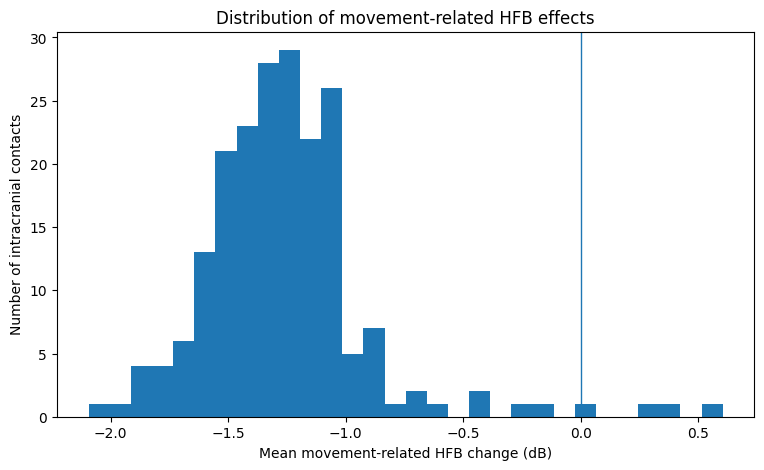

In [8]:
mean_hfb_by_channel = np.nanmean(hfb, axis=0)

movement_summary = intracranial_channels[
    ["channel_name", "implant_target"]
].copy()

movement_summary["mean_hfb_change_db"] = mean_hfb_by_channel
movement_summary["mean_beta_change_db"] = np.nanmean(beta, axis=0)
movement_summary["mean_120hz_change_db"] = np.nanmean(
    line120_change_db,
    axis=0,
)

print(
    f"Channels with negative mean HFB change: "
    f"{np.sum(mean_hfb_by_channel < 0)} / {len(mean_hfb_by_channel)}"
)

print(
    f"Median channel HFB change: "
    f"{np.nanmedian(mean_hfb_by_channel):.3f} dB"
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    mean_hfb_by_channel,
    bins=30,
)

ax.axvline(0, linewidth=1)
ax.set_xlabel("Mean movement-related HFB change (dB)")
ax.set_ylabel("Number of intracranial contacts")
ax.set_title("Distribution of movement-related HFB effects")

plt.show()


## A2. Is the HFB change globally shared from trial to trial?

For each trial, the median HFB change across all intracranial contacts is treated as a global/common component.

If nearly every channel strongly tracks this global value, that suggests the movement effect may contain a large common-mode component rather than being purely local.


Median trial-level global HFB change: -1.204 dB
Median channel correlation with global HFB: 0.836


,channel_name,implant_target,mean_hfb_change_db,mean_beta_change_db,mean_120hz_change_db,rho_with_global_hfb
117,BR7,R amygdala,-1.348841,-0.215700,-0.839500,0.965471
128,CR6,R hippocampal head,-1.499766,-0.134001,-0.882478,0.965424
116,BR6,R amygdala,-1.477600,-0.476085,-0.908856,0.961861
127,CR5,R hippocampal head,-1.558903,-0.327948,-0.994501,0.960689
115,BR5,R amygdala,-1.539739,-0.458326,-0.947193,0.959869
72,HL3,L anterior insula ventral,-1.475797,-0.281912,-0.903617,0.954923
126,CR4,R hippocampal head,-1.675480,-0.608920,-1.011482,0.951711
114,BR4,R amygdala,-1.578748,-0.543997,-0.913814,0.951289
76,HL7,L anterior insula ventral,-1.536590,0.228687,-1.031782,0.947375
27,CL6,L hippocampal head,-1.640107,-0.747631,-0.881989,0.946578


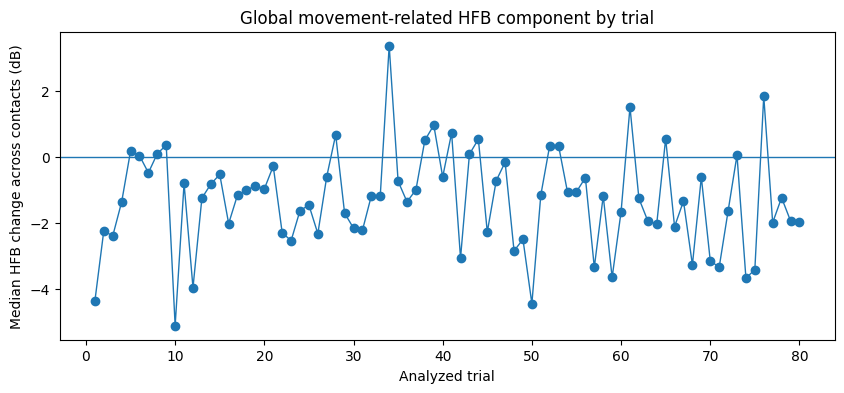

In [9]:
global_hfb_by_trial = np.nanmedian(
    hfb,
    axis=1,
)

global_correlation = np.full(
    hfb.shape[1],
    np.nan,
)

for ch in range(hfb.shape[1]):
    valid = (
        np.isfinite(global_hfb_by_trial)
        & np.isfinite(hfb[:, ch])
    )

    if valid.sum() >= 5:
        global_correlation[ch] = spearmanr(
            global_hfb_by_trial[valid],
            hfb[valid, ch],
        ).statistic

movement_summary["rho_with_global_hfb"] = global_correlation

print(
    f"Median trial-level global HFB change: "
    f"{np.nanmedian(global_hfb_by_trial):.3f} dB"
)

print(
    f"Median channel correlation with global HFB: "
    f"{np.nanmedian(global_correlation):.3f}"
)

display(
    movement_summary.sort_values(
        "rho_with_global_hfb",
        ascending=False,
    ).head(25)
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    np.arange(1, len(global_hfb_by_trial) + 1),
    global_hfb_by_trial,
    marker="o",
    linewidth=1,
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Analyzed trial")
ax.set_ylabel("Median HFB change across contacts (dB)")
ax.set_title("Global movement-related HFB component by trial")

plt.show()


## A3. Does the 120 Hz line-noise component change at movement onset?

The HFB calculation excluded the immediate 120 Hz harmonic, but a movement-related change in 120 Hz power can still reveal recording-wide electrical or movement-related contamination.


Median 120 Hz change across channels: -0.923 dB


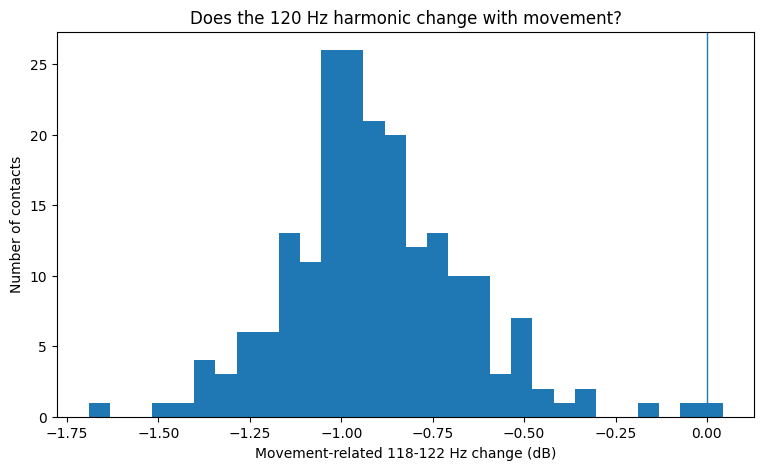

In [10]:
mean_120_by_channel = np.nanmean(
    line120_change_db,
    axis=0,
)

print(
    f"Median 120 Hz change across channels: "
    f"{np.nanmedian(mean_120_by_channel):.3f} dB"
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    mean_120_by_channel,
    bins=30,
)

ax.axvline(0, linewidth=1)
ax.set_xlabel("Movement-related 118-122 Hz change (dB)")
ax.set_ylabel("Number of contacts")
ax.set_title("Does the 120 Hz harmonic change with movement?")

plt.show()


## A4. Bipolar sensitivity analysis

Depth-electrode recordings often contain activity that is shared across nearby contacts or across the reference.

This section constructs adjacent-contact bipolar pairs within each electrode shaft:

```text
AL2 - AL1
AL3 - AL2
...
```

If the widespread HFB decrease largely disappears after bipolar referencing, the original effect may have a strong common-mode/reference component.

If it remains in specific local pairs, that supports a more spatially local effect.


In [11]:
bipolar_rows = []

for electrode, group in intracranial_channels.groupby(
    "electrode",
    observed=True,
):
    group = group.sort_values("contact").reset_index(drop=True)

    for i in range(len(group) - 1):
        a = group.iloc[i]
        b = group.iloc[i + 1]

        if int(b["contact"]) != int(a["contact"]) + 1:
            continue

        bipolar_rows.append({
            "pair_name": f"{b['channel_name']}-{a['channel_name']}",
            "electrode": electrode,
            "implant_target": a["implant_target"],
            "index_a": int(a["signal_index"]),
            "index_b": int(b["signal_index"]),
        })

bipolar_pairs = pd.DataFrame(bipolar_rows)

print(f"Adjacent bipolar pairs: {len(bipolar_pairs)}")

bipolar_hfb = []

for _, row in neural_trials.iterrows():
    onset = int(row["movement_onset_sample"])

    b0 = onset + int(round(BASELINE_WINDOW_S[0] * fs))
    b1 = onset + int(round(BASELINE_WINDOW_S[1] * fs))
    m0 = onset + int(round(MOVEMENT_WINDOW_S[0] * fs))
    m1 = onset + int(round(MOVEMENT_WINDOW_S[1] * fs))

    baseline_a = signal[
        b0:b1,
        bipolar_pairs["index_a"].to_numpy(),
    ].astype(np.float64)

    baseline_b = signal[
        b0:b1,
        bipolar_pairs["index_b"].to_numpy(),
    ].astype(np.float64)

    movement_a = signal[
        m0:m1,
        bipolar_pairs["index_a"].to_numpy(),
    ].astype(np.float64)

    movement_b = signal[
        m0:m1,
        bipolar_pairs["index_b"].to_numpy(),
    ].astype(np.float64)

    baseline_bipolar = baseline_b - baseline_a
    movement_bipolar = movement_b - movement_a

    f_b, psd_b = spectral_density(
        baseline_bipolar,
        fs,
    )
    f_m, psd_m = spectral_density(
        movement_bipolar,
        fs,
    )

    base_power = integrate_band(
        f_b,
        psd_b,
        70.0,
        150.0,
        remove_line_noise=True,
    )

    move_power = integrate_band(
        f_m,
        psd_m,
        70.0,
        150.0,
        remove_line_noise=True,
    )

    bipolar_hfb.append(
        10 * np.log10(
            (move_power + np.finfo(float).tiny)
            / (base_power + np.finfo(float).tiny)
        )
    )

bipolar_hfb = np.vstack(bipolar_hfb)

bipolar_results = bipolar_pairs[
    ["pair_name", "electrode", "implant_target"]
].copy()

bipolar_results["mean_hfb_change_db"] = np.nanmean(
    bipolar_hfb,
    axis=0,
)

test = ttest_1samp(
    bipolar_hfb,
    0,
    axis=0,
    nan_policy="omit",
)

bipolar_results["p"] = test.pvalue

def fdr_bh(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full(p_values.shape, np.nan)

    valid = np.isfinite(p_values)

    if not valid.any():
        return q_values

    p = p_values[valid]
    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)

    adjusted = (
        ranked * m
        / np.arange(1, m + 1)
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(adjusted, 0, 1)

    unsorted = np.empty_like(adjusted)
    unsorted[order] = adjusted

    q_values[valid] = unsorted

    return q_values

bipolar_results["q"] = fdr_bh(
    bipolar_results["p"].to_numpy()
)

print(
    f"Bipolar pairs with negative mean HFB change: "
    f"{(bipolar_results['mean_hfb_change_db'] < 0).sum()} / "
    f"{len(bipolar_results)}"
)

display(
    bipolar_results.sort_values("q").head(30)
)


Adjacent bipolar pairs: 184
Bipolar pairs with negative mean HFB change: 144 / 184


,pair_name,electrode,implant_target,mean_hfb_change_db,p,q
173,IR5-IR4,IR,R posterior insula,1.371732,1.433128e-14,2.636956e-12
183,IR15-IR14,IR,R posterior insula,-1.556680,1.328786e-11,1.222483e-09
155,HR15-HR14,HR,R anterior insula ventral,-1.271216,4.289381e-09,2.630820e-07
178,IR10-IR9,IR,R posterior insula,1.443483,1.172310e-08,5.392628e-07
15,AR8-AR7,AR,R temporal pole,-1.309303,4.048809e-08,1.489962e-06
8,AL10-AL9,AL,L temporal pole,-1.588075,9.215136e-08,2.422264e-06
86,EL6-EL5,EL,L fusiform,-1.159462,7.927268e-08,2.422264e-06
7,AL9-AL8,AL,L temporal pole,-1.527657,1.327869e-07,3.054098e-06
161,IL7-IL6,IL,L posterior insula,-1.169553,3.624308e-07,7.409697e-06
103,FL7-FL6,FL,L orbitofrontal,-1.055316,1.525685e-06,2.807261e-05


# Part B: Validate HL17 Ordered vs Pseudorandom

The first analysis found HL17, labeled on the implant sheet as left ventral anterior insula, as the strongest context-specific result.

This section looks at HL17 in more detail instead of reducing the entire result to one p-value.


In [13]:
CHANNEL_TO_VALIDATE = "HL17"

matches = np.flatnonzero(
    intracranial_names == CHANNEL_TO_VALIDATE
)

if matches.size != 1:
    raise ValueError(
        f"Could not uniquely identify {CHANNEL_TO_VALIDATE}"
    )

hl17_position = int(matches[0])
hl17_signal_index = int(
    intracranial_channels.loc[
        intracranial_channels["channel_name"] == CHANNEL_TO_VALIDATE,
        "signal_index",
    ].iloc[0]
)

hl17_hfb = hfb[:, hl17_position]

if "context" not in neural_trials.columns:
    raise KeyError("Task context could not be derived.")

ordered_mask = (
    neural_trials["context"] == "Ordered"
).to_numpy()

pseudo_mask = (
    neural_trials["context"] == "Pseudorandom"
).to_numpy()

print(f"Ordered trials: {ordered_mask.sum()}")
print(f"Pseudorandom trials: {pseudo_mask.sum()}")

print(
    f"Mean HL17 HFB, Ordered: "
    f"{np.nanmean(hl17_hfb[ordered_mask]):.3f} dB"
)

print(
    f"Mean HL17 HFB, Pseudorandom: "
    f"{np.nanmean(hl17_hfb[pseudo_mask]):.3f} dB"
)

print(
    f"Difference, Pseudorandom - Ordered: "
    f"{np.nanmean(hl17_hfb[pseudo_mask]) - np.nanmean(hl17_hfb[ordered_mask]):.3f} dB"
)

test = ttest_ind(
    hl17_hfb[pseudo_mask],
    hl17_hfb[ordered_mask],
    equal_var=False,
    nan_policy="omit",
)

print(f"Welch t-test p = {test.pvalue:.6g}")


Ordered trials: 20
Pseudorandom trials: 60
Mean HL17 HFB, Ordered: -1.511 dB
Mean HL17 HFB, Pseudorandom: 0.554 dB
Difference, Pseudorandom - Ordered: 2.065 dB
Welch t-test p = 0.000108863


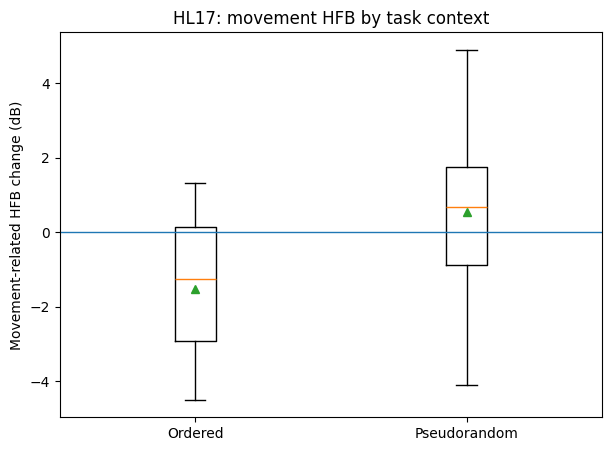

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [
        hl17_hfb[ordered_mask],
        hl17_hfb[pseudo_mask],
    ],
    tick_labels=[
        "Ordered",
        "Pseudorandom",
    ],
    showmeans=True,
)

ax.axhline(0, linewidth=1)
ax.set_ylabel("Movement-related HFB change (dB)")
ax.set_title("HL17: movement HFB by task context")

plt.show()


## B1. Time-resolved HL17 HFB around movement onset

This uses a 70 to 150 Hz bandpass, removes the 120 Hz component, calculates the Hilbert envelope, and baseline-normalizes each trial.

The goal is to see **when** the Ordered and Pseudorandom traces separate.


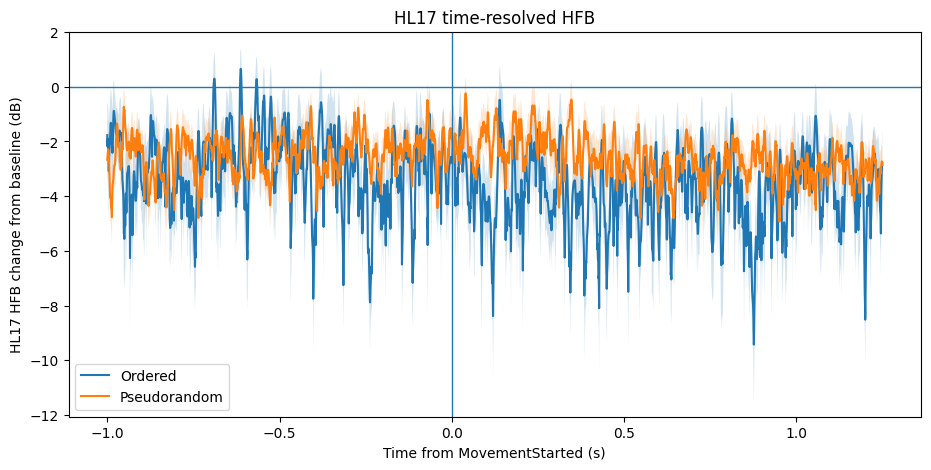

In [15]:
EVENT_WINDOW_S = (-1.25, 1.50)
PLOT_WINDOW_S = (-1.00, 1.25)
HFB_BAND = (70.0, 150.0)

sos = butter(
    4,
    HFB_BAND,
    btype="bandpass",
    fs=fs,
    output="sos",
)

b_notch, a_notch = iirnotch(
    120.0,
    Q=30.0,
    fs=fs,
)

event_times = np.arange(
    int(round(EVENT_WINDOW_S[0] * fs)),
    int(round(EVENT_WINDOW_S[1] * fs)),
) / fs

hl17_envelopes_db = []
kept_context = []

for _, row in neural_trials.iterrows():
    onset = int(row["movement_onset_sample"])

    start = onset + int(round(EVENT_WINDOW_S[0] * fs))
    stop = onset + int(round(EVENT_WINDOW_S[1] * fs))

    if start < 0 or stop > n_samples:
        continue

    x = signal[
        start:stop,
        hl17_signal_index,
    ].astype(np.float64)

    x = x - np.nanmean(x)
    x = np.nan_to_num(x)

    x = filtfilt(
        b_notch,
        a_notch,
        x,
    )

    x = sosfiltfilt(
        sos,
        x,
    )

    envelope_power = np.abs(
        hilbert(x)
    ) ** 2

    baseline_mask = (
        (event_times >= BASELINE_WINDOW_S[0])
        & (event_times <= BASELINE_WINDOW_S[1])
    )

    baseline_power = np.nanmean(
        envelope_power[baseline_mask]
    )

    envelope_db = 10 * np.log10(
        (envelope_power + np.finfo(float).tiny)
        / (baseline_power + np.finfo(float).tiny)
    )

    hl17_envelopes_db.append(envelope_db)
    kept_context.append(row["context"])

hl17_envelopes_db = np.vstack(
    hl17_envelopes_db
)

kept_context = np.asarray(kept_context)

ordered_time_mask = kept_context == "Ordered"
pseudo_time_mask = kept_context == "Pseudorandom"

plot_mask = (
    (event_times >= PLOT_WINDOW_S[0])
    & (event_times <= PLOT_WINDOW_S[1])
)

ordered_mean = np.nanmean(
    hl17_envelopes_db[ordered_time_mask],
    axis=0,
)

pseudo_mean = np.nanmean(
    hl17_envelopes_db[pseudo_time_mask],
    axis=0,
)

ordered_sem = (
    np.nanstd(
        hl17_envelopes_db[ordered_time_mask],
        axis=0,
        ddof=1,
    )
    / np.sqrt(ordered_time_mask.sum())
)

pseudo_sem = (
    np.nanstd(
        hl17_envelopes_db[pseudo_time_mask],
        axis=0,
        ddof=1,
    )
    / np.sqrt(pseudo_time_mask.sum())
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    event_times[plot_mask],
    ordered_mean[plot_mask],
    label="Ordered",
)

ax.fill_between(
    event_times[plot_mask],
    (ordered_mean - ordered_sem)[plot_mask],
    (ordered_mean + ordered_sem)[plot_mask],
    alpha=0.2,
)

ax.plot(
    event_times[plot_mask],
    pseudo_mean[plot_mask],
    label="Pseudorandom",
)

ax.fill_between(
    event_times[plot_mask],
    (pseudo_mean - pseudo_sem)[plot_mask],
    (pseudo_mean + pseudo_sem)[plot_mask],
    alpha=0.2,
)

ax.axvline(0, linewidth=1)
ax.axhline(0, linewidth=1)
ax.set_xlabel("Time from MovementStarted (s)")
ax.set_ylabel("HL17 HFB change from baseline (dB)")
ax.set_title("HL17 time-resolved HFB")
ax.legend()

plt.show()


## B2. HL17 time-frequency difference

This computes a short-time Fourier transform for each HL17 trial, baseline-normalizes each frequency, then plots:

```text
Pseudorandom minus Ordered
```

Positive values indicate greater spectral power in Pseudorandom trials at that time/frequency.


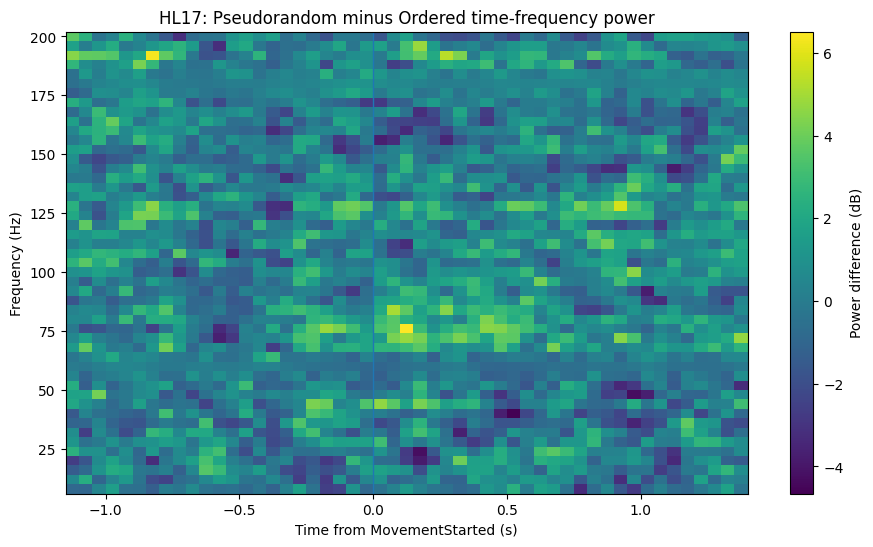

In [16]:
TF_WINDOW_S = (-1.25, 1.50)
TF_MAX_HZ = 200.0

tf_trials = []
tf_context = []
tf_frequencies = None
tf_times = None

for _, row in neural_trials.iterrows():
    onset = int(row["movement_onset_sample"])

    start = onset + int(round(TF_WINDOW_S[0] * fs))
    stop = onset + int(round(TF_WINDOW_S[1] * fs))

    if start < 0 or stop > n_samples:
        continue

    x = signal[
        start:stop,
        hl17_signal_index,
    ].astype(np.float64)

    x = x - np.nanmean(x)
    x = np.nan_to_num(x)

    x = filtfilt(
        b_notch,
        a_notch,
        x,
    )

    f_tf, t_tf, z_tf = stft(
        x,
        fs=fs,
        nperseg=int(round(0.25 * fs)),
        noverlap=int(round(0.20 * fs)),
        boundary=None,
        padded=False,
    )

    t_tf = t_tf + TF_WINDOW_S[0]

    power = np.abs(z_tf) ** 2

    freq_mask = (
        (f_tf >= 5)
        & (f_tf <= TF_MAX_HZ)
    )

    f_tf = f_tf[freq_mask]
    power = power[freq_mask]

    baseline_tf_mask = (
        (t_tf >= BASELINE_WINDOW_S[0])
        & (t_tf <= BASELINE_WINDOW_S[1])
    )

    baseline_spectrum = np.nanmean(
        power[:, baseline_tf_mask],
        axis=1,
        keepdims=True,
    )

    power_db = 10 * np.log10(
        (power + np.finfo(float).tiny)
        / (baseline_spectrum + np.finfo(float).tiny)
    )

    tf_trials.append(power_db)
    tf_context.append(row["context"])

    tf_frequencies = f_tf
    tf_times = t_tf

tf_trials = np.stack(tf_trials)
tf_context = np.asarray(tf_context)

ordered_tf = np.nanmean(
    tf_trials[tf_context == "Ordered"],
    axis=0,
)

pseudo_tf = np.nanmean(
    tf_trials[tf_context == "Pseudorandom"],
    axis=0,
)

difference_tf = pseudo_tf - ordered_tf

fig, ax = plt.subplots(figsize=(11, 6))

mesh = ax.pcolormesh(
    tf_times,
    tf_frequencies,
    difference_tf,
    shading="auto",
)

ax.axvline(0, linewidth=1)
ax.set_xlabel("Time from MovementStarted (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title(
    "HL17: Pseudorandom minus Ordered time-frequency power"
)

fig.colorbar(
    mesh,
    ax=ax,
    label="Power difference (dB)",
)

plt.show()


# Part C: Repair target-direction analysis

The earlier notebook found 77 different `TargetAngle` values across 80 trials, so an ANOVA requiring repeated identical angles was not useful.

This section first diagnoses the raw target information, then derives a geometric target direction from `TargetX` and `TargetY`, and finally fits a continuous circular tuning model.


In [17]:
if "TargetAngle" in neural_trials.columns:
    print(
        "Unique raw TargetAngle values:",
        neural_trials["TargetAngle"].nunique(),
    )

    display(
        neural_trials[
            ["trial", "TargetAngle"]
        ].head(25)
    )
else:
    print("TargetAngle was unavailable.")

target_columns = [
    col for col in [
        "TargetX_start",
        "TargetY_start",
        "TargetX_move",
        "TargetY_move",
        "TargetX_hit",
        "TargetY_hit",
    ]
    if col in neural_trials.columns
]

print("\nTarget coordinate columns:")
print(target_columns)

if target_columns:
    display(
        neural_trials[
            ["trial"] + target_columns
        ].head(25)
    )


Unique raw TargetAngle values: 77


,trial,TargetAngle
0,1,1276
1,2,2256
2,3,1509
3,4,1253
4,5,2441
5,6,210
6,7,1274
7,8,2136
8,9,3353
9,10,3008



Target coordinate columns:
['TargetX_start', 'TargetY_start', 'TargetX_move', 'TargetY_move', 'TargetX_hit', 'TargetY_hit']


,trial,TargetX_start,TargetY_start,TargetX_move,TargetY_move,TargetX_hit,TargetY_hit
0,1,359,776,359,776,359,776
1,2,336,273,336,273,336,273
2,3,293,674,293,674,293,674
3,4,367,784,367,784,367,784
4,5,402,211,402,211,402,211
5,6,745,631,745,631,745,631
6,7,359,777,359,777,359,777
7,8,303,327,303,327,303,327
8,9,739,372,739,372,739,372
9,10,640,224,640,224,640,224


## C1. Derive target direction from X/Y coordinates

The movement-onset target coordinates are used by default.

The center is estimated from the median target X and Y across trials. For a symmetric target layout, this gives the central point around which target direction can be calculated.

The result is a continuous angle in degrees from 0 to 360.


Estimated target center: X=454.000, Y=568.000
Unique exact TargetX/TargetY pairs: 77


,trial,TargetX_move,TargetY_move,target_direction_xy_deg
0,1,359,776,245.452361
1,2,336,273,111.801409
2,3,293,674,213.360311
3,4,367,784,248.061520
4,5,402,211,98.287323
5,6,745,631,347.784281
6,7,359,777,245.556045
7,8,303,327,122.069449
8,9,739,372,34.517054
9,10,640,224,61.600014


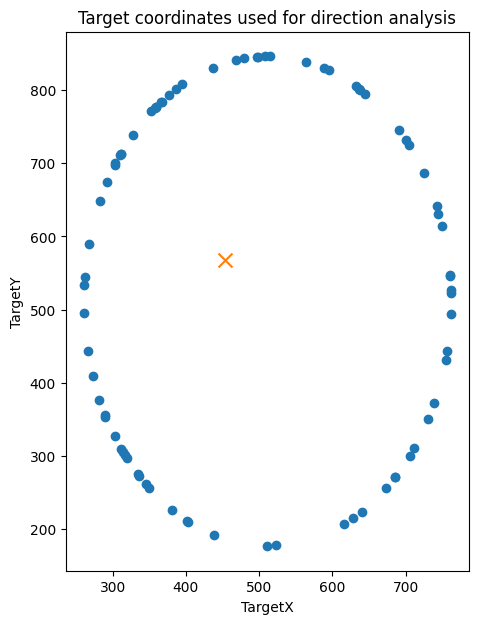

In [18]:
if (
    "TargetX_move" not in neural_trials.columns
    or "TargetY_move" not in neural_trials.columns
):
    raise KeyError(
        "TargetX and TargetY are required for geometric direction analysis."
    )

target_x = neural_trials["TargetX_move"].astype(float).to_numpy()
target_y = neural_trials["TargetY_move"].astype(float).to_numpy()

center_x = np.nanmedian(target_x)
center_y = np.nanmedian(target_y)

dx = target_x - center_x
dy = target_y - center_y

target_direction_deg = (
    np.degrees(
        np.arctan2(
            -dy,
            dx,
        )
    )
    % 360
)

neural_trials["target_direction_xy_deg"] = target_direction_deg

print(f"Estimated target center: X={center_x:.3f}, Y={center_y:.3f}")
print(
    f"Unique exact TargetX/TargetY pairs: "
    f"{neural_trials[['TargetX_move', 'TargetY_move']].drop_duplicates().shape[0]}"
)

display(
    neural_trials[
        [
            "trial",
            "TargetX_move",
            "TargetY_move",
            "target_direction_xy_deg",
        ]
    ].head(25)
)

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    target_x,
    target_y,
)

ax.scatter(
    [center_x],
    [center_y],
    marker="x",
    s=100,
)

ax.set_xlabel("TargetX")
ax.set_ylabel("TargetY")
ax.set_title("Target coordinates used for direction analysis")
ax.set_aspect("equal", adjustable="box")

plt.show()


## C2. Continuous circular tuning model

For each intracranial channel:

```text
HFB = intercept + beta_cos*cos(theta) + beta_sin*sin(theta)
```

This tests whether movement-related HFB changes systematically with target direction without requiring repeated identical target angles.

The model reports:

- F statistic
- p-value
- FDR q-value
- R-squared
- estimated preferred direction


In [19]:
def circular_direction_test(y, theta_deg):
    y = np.asarray(y, dtype=float)
    theta_deg = np.asarray(theta_deg, dtype=float)

    valid = (
        np.isfinite(y)
        & np.isfinite(theta_deg)
    )

    y = y[valid]
    theta = np.deg2rad(theta_deg[valid])

    if len(y) < 10:
        return {
            "F": np.nan,
            "p": np.nan,
            "r2": np.nan,
            "preferred_direction_deg": np.nan,
        }

    X_full = np.column_stack([
        np.ones(len(y)),
        np.cos(theta),
        np.sin(theta),
    ])

    beta_hat, _, _, _ = np.linalg.lstsq(
        X_full,
        y,
        rcond=None,
    )

    predicted = X_full @ beta_hat

    ss_res = np.sum(
        (y - predicted) ** 2
    )

    ss_total = np.sum(
        (y - np.mean(y)) ** 2
    )

    if ss_total <= 0:
        return {
            "F": np.nan,
            "p": np.nan,
            "r2": np.nan,
            "preferred_direction_deg": np.nan,
        }

    ss_model = ss_total - ss_res

    df_model = 2
    df_resid = len(y) - 3

    if df_resid <= 0 or ss_res <= 0:
        return {
            "F": np.nan,
            "p": np.nan,
            "r2": np.nan,
            "preferred_direction_deg": np.nan,
        }

    F_value = (
        (ss_model / df_model)
        / (ss_res / df_resid)
    )

    p_value = f_distribution.sf(
        F_value,
        df_model,
        df_resid,
    )

    r2 = 1 - (
        ss_res / ss_total
    )

    preferred_direction = (
        np.degrees(
            np.arctan2(
                beta_hat[2],
                beta_hat[1],
            )
        )
        % 360
    )

    return {
        "F": F_value,
        "p": p_value,
        "r2": r2,
        "preferred_direction_deg": preferred_direction,
    }


direction_rows = []

for ch in range(hfb.shape[1]):
    result = circular_direction_test(
        hfb[:, ch],
        neural_trials["target_direction_xy_deg"].to_numpy(),
    )

    direction_rows.append(result)

direction_results = intracranial_channels[
    [
        "channel_name",
        "implant_target",
    ]
].copy()

direction_results["F"] = [
    row["F"]
    for row in direction_rows
]

direction_results["p"] = [
    row["p"]
    for row in direction_rows
]

direction_results["r2"] = [
    row["r2"]
    for row in direction_rows
]

direction_results["preferred_direction_deg"] = [
    row["preferred_direction_deg"]
    for row in direction_rows
]

direction_results["q"] = fdr_bh(
    direction_results["p"].to_numpy()
)

display(
    direction_results.sort_values("q").head(30)
)


,channel_name,implant_target,F,p,r2,preferred_direction_deg,q
98,IL11,L posterior insula,10.586911,0.000087,0.215677,176.701991,0.017515
178,HR7,R anterior insula ventral,6.987231,0.001627,0.153609,2.596914,0.164367
3,AL4,L temporal pole,0.576073,0.564505,0.014742,95.213447,0.870040
0,AL1,L temporal pole,0.251746,0.778080,0.006496,120.868788,0.870040
6,AL7,L temporal pole,0.544218,0.582511,0.013939,97.074693,0.870040
5,AL6,L temporal pole,0.312530,0.732518,0.008052,100.894041,0.870040
7,AL8,L temporal pole,0.780760,0.461650,0.019876,102.261399,0.870040
2,AL3,L temporal pole,0.252695,0.777346,0.006521,101.423316,0.870040
15,BL6,L amygdala,0.335417,0.716079,0.008637,107.824240,0.870040
9,AL10,L temporal pole,1.290520,0.281011,0.032433,114.005061,0.870040


## C3. Visualize the strongest direction-tuned candidate

The plot bins directions only for visualization. The statistical model above used the continuous angle values.


Top direction candidate: IL11
q = 0.01751, R^2 = 0.216, preferred direction = 176.7 degrees


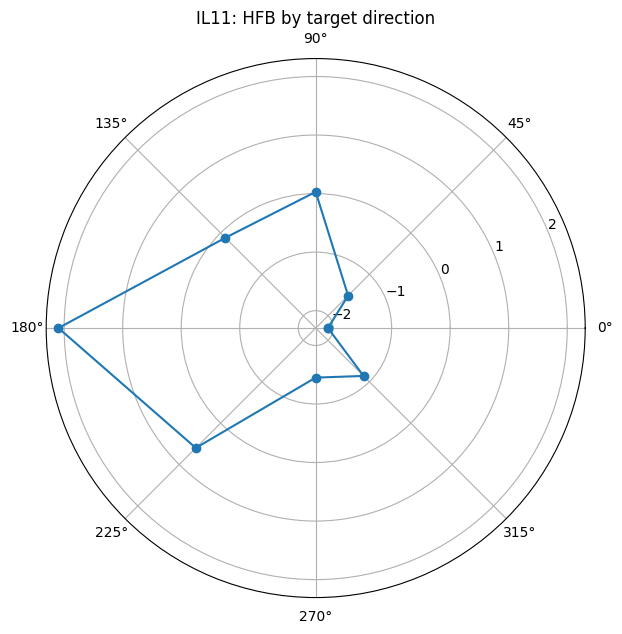

In [20]:
top_direction_channel = (
    direction_results
    .sort_values("q")
    .iloc[0]["channel_name"]
)

top_position = int(
    np.flatnonzero(
        intracranial_names == top_direction_channel
    )[0]
)

theta = neural_trials[
    "target_direction_xy_deg"
].to_numpy()

response = hfb[:, top_position]

BIN_WIDTH_DEG = 45.0
bin_centers = np.arange(
    0,
    360,
    BIN_WIDTH_DEG,
)

binned_mean = []

for center in bin_centers:
    angular_difference = np.abs(
        (
            (theta - center + 180)
            % 360
        )
        - 180
    )

    mask = (
        angular_difference
        <= BIN_WIDTH_DEG / 2
    )

    if mask.sum() > 0:
        binned_mean.append(
            np.nanmean(response[mask])
        )
    else:
        binned_mean.append(np.nan)

print(f"Top direction candidate: {top_direction_channel}")

top_info = direction_results.loc[
    direction_results["channel_name"] == top_direction_channel
].iloc[0]

print(
    f"q = {top_info['q']:.4g}, "
    f"R^2 = {top_info['r2']:.3f}, "
    f"preferred direction = "
    f"{top_info['preferred_direction_deg']:.1f} degrees"
)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="polar")

angles_rad = np.deg2rad(
    np.r_[bin_centers, bin_centers[0]]
)

values_closed = np.r_[
    binned_mean,
    binned_mean[0],
]

ax.plot(
    angles_rad,
    values_closed,
    marker="o",
)

ax.set_title(
    f"{top_direction_channel}: HFB by target direction"
)

plt.show()


# Part D: Eye-tracking analysis

The file contains explicit gaze coordinates and other eye-tracking states.

This section first inspects their ranges, then creates a combined binocular gaze trace and summarizes gaze movement before joystick movement begins.


In [21]:
eye_related = [
    name
    for name in states
    if (
        "eye" in name.lower()
        or "gaze" in name.lower()
    )
]

print("Eye/gaze states available:")

for name in eye_related:
    values = np.asarray(states[name])

    print(
        f"{name}: "
        f"min={np.nanmin(values):.3f}, "
        f"max={np.nanmax(values):.3f}, "
        f"unique={np.unique(values).size}"
    )


Eye/gaze states available:
EyetrackerTime: min=0.000, max=65535.000, unique=55592
EyetrackerLeftEyeValidity: min=0.000, max=4.000, unique=2
EyetrackerLeftEyeOpennessValidity: min=0.000, max=0.000, unique=1
EyetrackerLeftPupilSize: min=0.000, max=324.000, unique=139
EyetrackerLeftEyeOpenness: min=0.000, max=0.000, unique=1
EyetrackerLeftEyeGazeX: min=0.000, max=42707.000, unique=4383
EyetrackerLeftEyeGazeY: min=0.000, max=36020.000, unique=2684
EyetrackerLeftEyePosX: min=0.000, max=36760.000, unique=849
EyetrackerLeftEyePosY: min=0.000, max=34090.000, unique=362
EyetrackerLeftEyeDist: min=0.000, max=39910.000, unique=1169
EyetrackerRightEyeValidity: min=0.000, max=4.000, unique=2
EyetrackerRightEyeOpennessValidity: min=0.000, max=0.000, unique=1
EyetrackerRightPupilSize: min=0.000, max=326.000, unique=131
EyetrackerRightEyeOpenness: min=0.000, max=0.000, unique=1
EyetrackerRightEyeGazeX: min=0.000, max=40894.000, unique=4007
EyetrackerRightEyeGazeY: min=0.000, max=35942.000, unique=2457

## D1. Build a combined binocular gaze trace

If both left and right gaze coordinates are available, the notebook averages them sample by sample.

No validity code is assumed here because the exact meaning of the validity values should be confirmed from the eye-tracker configuration. The validity-state distributions are printed separately so you can inspect them.


In [22]:
left_x_name = "EyetrackerLeftEyeGazeX"
left_y_name = "EyetrackerLeftEyeGazeY"
right_x_name = "EyetrackerRightEyeGazeX"
right_y_name = "EyetrackerRightEyeGazeY"

required_gaze = [
    left_x_name,
    left_y_name,
    right_x_name,
    right_y_name,
]

missing_gaze = [
    name
    for name in required_gaze
    if name not in states
]

if missing_gaze:
    raise KeyError(
        "Missing gaze-coordinate states: "
        + ", ".join(missing_gaze)
    )

left_x = states[left_x_name].astype(float)
left_y = states[left_y_name].astype(float)
right_x = states[right_x_name].astype(float)
right_y = states[right_y_name].astype(float)

gaze_x = np.nanmean(
    np.vstack([left_x, right_x]),
    axis=0,
)

gaze_y = np.nanmean(
    np.vstack([left_y, right_y]),
    axis=0,
)

for validity_name in [
    "EyetrackerLeftEyeValidity",
    "EyetrackerRightEyeValidity",
]:
    if validity_name in states:
        values, counts = np.unique(
            states[validity_name],
            return_counts=True,
        )

        print(f"\n{validity_name}:")
        display(
            pd.DataFrame({
                "value": values,
                "count": counts,
            })
        )

print(
    f"Gaze X range: {np.nanmin(gaze_x):.3f} to {np.nanmax(gaze_x):.3f}"
)

print(
    f"Gaze Y range: {np.nanmin(gaze_y):.3f} to {np.nanmax(gaze_y):.3f}"
)



EyetrackerLeftEyeValidity:


,value,count
0,0,1186644
1,4,68456



EyetrackerRightEyeValidity:


,value,count
0,0,1135580
1,4,119520


Gaze X range: 0.000 to 40916.000
Gaze Y range: 0.000 to 35971.000


## D2. Use eye-tracker update times when available

Eye-tracking states are stored alongside the 2000 Hz neural stream, but the eye tracker itself usually updates more slowly.

If `EyetrackerTime` exists, only samples where that timestamp changes are used as eye-tracker updates. This avoids counting repeated copied gaze values as new gaze samples.


In [23]:
if "EyetrackerTime" in states:
    eye_time = states["EyetrackerTime"]

    eye_update_indices = np.r_[
        0,
        np.flatnonzero(
            np.diff(eye_time) != 0
        ) + 1,
    ]
else:
    eye_update_indices = np.arange(
        0,
        n_samples,
        max(1, int(round(fs / 120))),
    )

print(
    f"Eye update samples retained: "
    f"{len(eye_update_indices):,}"
)

if len(eye_update_indices) > 1:
    update_intervals = np.diff(
        eye_update_indices
    ) / fs

    print(
        f"Median eye update interval: "
        f"{np.nanmedian(update_intervals) * 1000:.2f} ms"
    )


Eye update samples retained: 75,120
Median eye update interval: 8.00 ms


## D3. Trial-level gaze behavior before joystick movement

For each trial, from trial start until `MovementStarted`, the notebook calculates:

- gaze path length
- gaze shift from the early-trial position to the pre-movement position
- median pupil size when available

These values do not require gaze coordinates to use the same units as `TargetX` and `TargetY`.


In [25]:
left_pupil_name = "EyetrackerLeftPupilSize"
right_pupil_name = "EyetrackerRightPupilSize"

if left_pupil_name in states and right_pupil_name in states:
    pupil = np.nanmean(
        np.vstack([
            states[left_pupil_name].astype(float),
            states[right_pupil_name].astype(float),
        ]),
        axis=0,
    )
else:
    pupil = None

gaze_rows = []

for _, row in neural_trials.iterrows():
    start = int(row["trial_start_sample"])
    onset = int(row["movement_onset_sample"])

    idx = eye_update_indices[
        (eye_update_indices >= start)
        & (eye_update_indices <= onset)
    ]

    if len(idx) < 3:
        gaze_rows.append({
            "gaze_path_pre_movement": np.nan,
            "gaze_shift_pre_movement": np.nan,
            "pupil_pre_movement": np.nan,
        })
        continue

    gx = gaze_x[idx]
    gy = gaze_y[idx]

    valid = (
        np.isfinite(gx)
        & np.isfinite(gy)
    )

    gx = gx[valid]
    gy = gy[valid]

    if len(gx) < 3:
        gaze_rows.append({
            "gaze_path_pre_movement": np.nan,
            "gaze_shift_pre_movement": np.nan,
            "pupil_pre_movement": np.nan,
        })
        continue

    step = np.hypot(
        np.diff(gx),
        np.diff(gy),
    )

    gaze_path = np.nansum(step)

    n_edge = min(
        3,
        max(1, len(gx) // 3),
    )

    early_x = np.nanmedian(
        gx[:n_edge]
    )
    early_y = np.nanmedian(
        gy[:n_edge]
    )

    late_x = np.nanmedian(
        gx[-n_edge:]
    )
    late_y = np.nanmedian(
        gy[-n_edge:]
    )

    gaze_shift = np.hypot(
        late_x - early_x,
        late_y - early_y,
    )

    if pupil is not None:
        pupil_value = np.nanmedian(
            pupil[idx]
        )
    else:
        pupil_value = np.nan

    gaze_rows.append({
        "gaze_path_pre_movement": gaze_path,
        "gaze_shift_pre_movement": gaze_shift,
        "pupil_pre_movement": pupil_value,
    })

gaze_trial_table = pd.DataFrame(
    gaze_rows
)

for column in gaze_trial_table:
    neural_trials[column] = gaze_trial_table[column].to_numpy()

display(
    neural_trials[
        [
            "trial",
            "context",
            "condition",
            "gaze_path_pre_movement",
            "gaze_shift_pre_movement",
            "pupil_pre_movement",
        ]
    ].head(20)
)


,trial,context,condition,gaze_path_pre_movement,gaze_shift_pre_movement,pupil_pre_movement
0,1,Ordered,Automatic,23587.374604,1509.135514,234.50
1,2,Ordered,Automatic,12373.894655,1509.079604,233.50
2,3,Ordered,Automatic,14370.422540,1219.397495,242.50
3,4,Ordered,Automatic,11039.710690,423.709806,234.00
4,5,Ordered,Automatic,9154.966689,22.051077,226.50
5,6,Ordered,Automatic,24355.103588,2204.553299,231.00
6,7,Ordered,Automatic,22435.734514,1356.560817,232.00
7,8,Ordered,Automatic,11349.870408,1152.340336,237.00
8,9,Ordered,Automatic,12214.224056,2260.125273,236.50
9,10,Ordered,Automatic,16700.674309,662.127631,238.00


## D4. Correlate gaze behavior with neural HFB

This tests whether trial-to-trial variation in pre-movement gaze behavior is associated with movement-related HFB in any intracranial contact.


In [26]:
def channelwise_spearman(
    response_matrix,
    behavior,
):
    behavior = np.asarray(
        behavior,
        dtype=float,
    )

    rho = np.full(
        response_matrix.shape[1],
        np.nan,
    )

    p = np.full(
        response_matrix.shape[1],
        np.nan,
    )

    for ch in range(
        response_matrix.shape[1]
    ):
        neural = response_matrix[:, ch]

        valid = (
            np.isfinite(neural)
            & np.isfinite(behavior)
        )

        if valid.sum() < 8:
            continue

        if np.unique(
            behavior[valid]
        ).size < 2:
            continue

        stat = spearmanr(
            neural[valid],
            behavior[valid],
        )

        rho[ch] = stat.statistic
        p[ch] = stat.pvalue

    return rho, p, fdr_bh(p)


gaze_correlation_results = intracranial_channels[
    [
        "channel_name",
        "implant_target",
    ]
].copy()

for behavior_column in [
    "gaze_path_pre_movement",
    "gaze_shift_pre_movement",
    "pupil_pre_movement",
]:
    rho, p, q = channelwise_spearman(
        hfb,
        neural_trials[behavior_column].to_numpy(),
    )

    gaze_correlation_results[
        f"{behavior_column}_rho"
    ] = rho

    gaze_correlation_results[
        f"{behavior_column}_p"
    ] = p

    gaze_correlation_results[
        f"{behavior_column}_q"
    ] = q

display(
    gaze_correlation_results.sort_values(
        "gaze_shift_pre_movement_q"
    ).head(30)
)


,channel_name,implant_target,gaze_path_pre_movement_rho,gaze_path_pre_movement_p,gaze_path_pre_movement_q,gaze_shift_pre_movement_rho,gaze_shift_pre_movement_p,gaze_shift_pre_movement_q,pupil_pre_movement_rho,pupil_pre_movement_p,pupil_pre_movement_q
1,AL2,L temporal pole,-0.181247,0.107624,0.979242,0.175481,0.119482,0.614828,0.017905,0.874743,0.993988
2,AL3,L temporal pole,-0.103657,0.360186,0.979242,0.156188,0.166508,0.614828,0.027871,0.806136,0.993988
5,AL6,L temporal pole,-0.100375,0.375676,0.979242,0.157079,0.164073,0.614828,-0.043748,0.700002,0.993988
4,AL5,L temporal pole,-0.085959,0.448365,0.979242,0.130028,0.250312,0.614828,0.010553,0.925979,0.993988
6,AL7,L temporal pole,-0.071542,0.528281,0.979242,0.123254,0.276056,0.614828,0.030052,0.791298,0.993988
7,AL8,L temporal pole,-0.021566,0.849405,0.979242,0.171261,0.128777,0.614828,0.022958,0.839806,0.993988
15,BL6,L amygdala,-0.106845,0.345521,0.979242,0.135818,0.229654,0.614828,-0.016322,0.885738,0.993988
8,AL9,L temporal pole,0.056774,0.616921,0.979242,0.139897,0.215835,0.614828,-0.038624,0.733743,0.993988
14,BL5,L amygdala,-0.145617,0.197462,0.979242,0.132700,0.240625,0.614828,-0.031530,0.781288,0.993988
13,BL4,L amygdala,-0.163713,0.146764,0.979242,0.147820,0.190692,0.614828,-0.037228,0.743022,0.993988


## D5. Does gaze behavior differ between Ordered and Pseudorandom trials?

This is useful because HL17 differed by context. If gaze behavior also differs strongly by context, gaze could be one behavioral factor contributing to the HL17 effect.


In [27]:
if "context" in neural_trials.columns:
    for behavior_column in [
        "gaze_path_pre_movement",
        "gaze_shift_pre_movement",
        "pupil_pre_movement",
    ]:
        ordered_values = neural_trials.loc[
            neural_trials["context"] == "Ordered",
            behavior_column,
        ].dropna()

        pseudo_values = neural_trials.loc[
            neural_trials["context"] == "Pseudorandom",
            behavior_column,
        ].dropna()

        if len(ordered_values) >= 2 and len(pseudo_values) >= 2:
            test = ttest_ind(
                pseudo_values,
                ordered_values,
                equal_var=False,
                nan_policy="omit",
            )

            print(
                f"{behavior_column}: "
                f"Ordered mean={ordered_values.mean():.3f}, "
                f"Pseudorandom mean={pseudo_values.mean():.3f}, "
                f"p={test.pvalue:.6g}"
            )


gaze_path_pre_movement: Ordered mean=15048.221, Pseudorandom mean=18020.799, p=0.0282728
gaze_shift_pre_movement: Ordered mean=1268.907, Pseudorandom mean=1135.603, p=0.392844
pupil_pre_movement: Ordered mean=236.050, Pseudorandom mean=245.550, p=1.51589e-07


## D6. Does HL17 track gaze behavior?

Because HL17 was the main context-sensitive neural candidate, this directly tests whether its HFB response correlates with the gaze summary measures.


In [28]:
for behavior_column in [
    "gaze_path_pre_movement",
    "gaze_shift_pre_movement",
    "pupil_pre_movement",
]:
    behavior = neural_trials[
        behavior_column
    ].to_numpy()

    valid = (
        np.isfinite(behavior)
        & np.isfinite(hl17_hfb)
    )

    if valid.sum() >= 8:
        stat = spearmanr(
            behavior[valid],
            hl17_hfb[valid],
        )

        print(
            f"HL17 vs {behavior_column}: "
            f"rho={stat.statistic:.3f}, "
            f"p={stat.pvalue:.6g}"
        )


HL17 vs gaze_path_pre_movement: rho=0.114, p=0.312613
HL17 vs gaze_shift_pre_movement: rho=-0.064, p=0.570112
HL17 vs pupil_pre_movement: rho=0.242, p=0.0308045


# Part E: Compact follow-up summary

This final cell gathers the most useful outputs into one place:

- strongest context-sensitive channel
- strongest direction-tuned channel
- whether movement HFB is globally negative
- whether the global effect survives bipolar referencing
- strongest gaze-HFB candidate


In [29]:
summary_rows = []

# HL17 context effect
if "context" in neural_trials.columns:
    summary_rows.append({
        "analysis": "HL17 context effect",
        "result": (
            f"Pseudorandom - Ordered HFB = "
            f"{np.nanmean(hl17_hfb[pseudo_mask]) - np.nanmean(hl17_hfb[ordered_mask]):.3f} dB"
        ),
    })

# Global movement HFB
summary_rows.append({
    "analysis": "Global movement HFB",
    "result": (
        f"{np.sum(mean_hfb_by_channel < 0)} / "
        f"{len(mean_hfb_by_channel)} contacts have negative mean HFB change"
    ),
})

# Bipolar movement HFB
summary_rows.append({
    "analysis": "Bipolar movement HFB",
    "result": (
        f"{(bipolar_results['mean_hfb_change_db'] < 0).sum()} / "
        f"{len(bipolar_results)} adjacent pairs have negative mean HFB change"
    ),
})

# Direction tuning
top_direction = (
    direction_results
    .sort_values("q")
    .iloc[0]
)

summary_rows.append({
    "analysis": "Top target-direction candidate",
    "result": (
        f"{top_direction['channel_name']} | "
        f"q={top_direction['q']:.4g} | "
        f"R^2={top_direction['r2']:.3f} | "
        f"preferred={top_direction['preferred_direction_deg']:.1f} deg"
    ),
})

# Gaze
top_gaze = (
    gaze_correlation_results
    .sort_values("gaze_shift_pre_movement_q")
    .iloc[0]
)

summary_rows.append({
    "analysis": "Top gaze-shift candidate",
    "result": (
        f"{top_gaze['channel_name']} | "
        f"rho={top_gaze['gaze_shift_pre_movement_rho']:.3f} | "
        f"q={top_gaze['gaze_shift_pre_movement_q']:.4g}"
    ),
})

final_summary = pd.DataFrame(
    summary_rows
)

display(final_summary)


,analysis,result
0,HL17 context effect,Pseudorandom - Ordered HFB = 2.065 dB
1,Global movement HFB,198 / 202 contacts have negative mean HFB change
2,Bipolar movement HFB,144 / 184 adjacent pairs have negative mean HF...
3,Top target-direction candidate,IL11 | q=0.01751 | R^2=0.216 | preferred=176.7...
4,Top gaze-shift candidate,AL2 | rho=0.175 | q=0.6148


# Interpretation guide

The main follow-up questions are:

**HL17:** Does its context effect appear as a localized, repeatable separation in the time-resolved HFB trace, or is it driven by a few trials?

**Widespread HFB decrease:** Does it persist after adjacent-contact bipolar referencing? If not, the original movement effect likely contains a substantial common-mode/reference component.

**120 Hz:** Does line-noise power itself change around movement? A large global change would make artifact or recording-condition changes more plausible.

**Target direction:** Do any channels survive FDR in the continuous circular regression? This is a better directional test than requiring repeated identical `TargetAngle` values.

**Eye tracking:** Do gaze path, gaze shift, or pupil size differ by context or correlate with specific neural contacts? If HL17 also tracks gaze behavior, gaze may be one component of the Ordered/Pseudorandom effect.

All significant channels should still be checked for signal quality, reference dependence, trial consistency, and contact-level localization on post-implant imaging.
